In [2]:
import sys
print(sys.executable)

/Users/lina/code/mlr-clustering-reserving/.venv/bin/python


## # SPLICE Complexity 5 — Data Exploration

## Objective

This notebook explores and validates the SPLICE Complexity 5 dataset before defining the clustering unit and constructing actuarial features.

The immediate objectives are to:

- understand the claim, payment and incurred tables;
- verify their dimensions, identifiers and missing values;
- understand how the tables relate through `claim_no`;
- determine whether clustering should be performed at claim level or on aggregated portfolio segments.

Clustering methods are developed separately in `02_clustering_experiments.ipynb`.

In [4]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "raw" / "splice" / "complexity_5"

claims = pd.read_csv(DATA / "claim_5.csv", index_col=0)
payments = pd.read_csv(DATA / "payment_5.csv", index_col=0)
incurred = pd.read_csv(DATA / "incurred_5.csv", index_col=0)

print("Claims:", claims.shape)
print("Payments:", payments.shape)
print("Incurred:", incurred.shape)

Claims: (3663, 7)
Payments: (19322, 12)
Incurred: (31554, 9)


## Dataset structure

The scenario contains three connected tables:

| Table | Observation unit | Purpose |
|---|---|---|
| `claim_5.csv` | One row per claim | Claim-level characteristics and final outcomes |
| `payment_5.csv` | One row per payment | Timing and amount of individual claim payments |
| `incurred_5.csv` | One row per transaction event | Evolution of incurred amounts and outstanding claim liabilities |

The tables are linked through the unique claim identifier `claim_no`.

The first records are displayed below to confirm the structure and interpretation of each table.

In [5]:
display(claims.head())
display(payments.head())
display(incurred.head())

,claim_no,occurrence_period,occurrence_time,claim_size,notidel,setldel,no_payment
1,1,1,0.734094,232310.088225,1.131285,32.367417,5
2,2,1,0.333072,237675.124402,1.264990,29.044041,5
3,3,1,0.515063,83559.574229,1.862734,7.149905,6
4,4,1,0.743975,227599.310366,0.723529,16.412921,5
5,5,1,0.619159,119227.153293,3.183924,3.708863,5


,claim_no,pmt_no,occurrence_period,occurrence_time,claim_size,notidel,setldel,payment_time,payment_period,payment_size,payment_inflated,payment_delay
1,1,1,1,0.734094,232310.088225,1.131285,32.367417,7.350589,8,13226.339829,13716.514232,5.485209
2,1,2,1,0.734094,232310.088225,1.131285,32.367417,13.989923,14,15685.858503,16810.755379,6.639334
3,1,3,1,0.734094,232310.088225,1.131285,32.367417,25.051429,26,14643.284608,16576.779144,11.061506
4,1,4,1,0.734094,232310.088225,1.131285,32.367417,31.735890,32,170041.893330,198970.851789,6.684462
5,1,5,1,0.734094,232310.088225,1.131285,32.367417,34.232797,35,18712.711956,22168.622922,2.496907


,claim_no,claim_size,txn_time,txn_delay,txn_type,incurred,OCL,cumpaid,multiplier
1,1,232310.088225,1.865380,0.000000,Ma,31291.711834,31291.711834,0.000000,1.000000
2,1,232310.088225,7.350589,5.485209,P,31291.711834,17575.197602,13716.514232,NaN
3,1,232310.088225,13.989923,12.124543,PMi,32133.968012,1606.698401,30527.269611,0.941405
4,1,232310.088225,14.230048,12.364669,Ma,133072.857153,102545.587542,30527.269611,7.748798
5,1,232310.088225,14.409033,12.543653,Ma,314565.316682,284038.047071,30527.269611,2.361764


## Initial data validation

Before feature engineering, the following checks are performed:

1. Confirm that `claim_no` is unique in the claim table.
2. Count the claims represented in each transactional table.
3. Identify missing values.
4. Distinguish expected structural missingness from possible data-quality problems.

No raw values are modified during this validation.

In [6]:
print("Unique claim rows:", claims["claim_no"].is_unique)
print("Claims in claims table:", claims["claim_no"].nunique())
print("Claims represented in payments:", payments["claim_no"].nunique())
print("Claims represented in incurred:", incurred["claim_no"].nunique())

print("\nMissing values — claims")
display(claims.isna().sum())

print("\nMissing values — payments")
display(payments.isna().sum())

print("\nMissing values — incurred")
display(incurred.isna().sum())

Unique claim rows: True
Claims in claims table: 3663
Claims represented in payments: 3663
Claims represented in incurred: 3663

Missing values — claims


claim_no             0
occurrence_period    0
occurrence_time      0
claim_size           0
notidel              0
setldel              0
no_payment           0
dtype: int64


Missing values — payments


claim_no             0
pmt_no               0
occurrence_period    0
occurrence_time      0
claim_size           0
notidel              0
setldel              0
payment_time         0
payment_period       0
payment_size         0
payment_inflated     0
payment_delay        0
dtype: int64


Missing values — incurred


claim_no         0
claim_size       0
txn_time         0
txn_delay        0
txn_type         0
incurred         0
OCL              0
cumpaid          0
multiplier    9593
dtype: int64

## Referential integrity

The transactional tables should contain only claims present in the claim table.  
The number of payment rows per claim should also agree with `no_payment`.

In [8]:
claim_ids = set(claims["claim_no"])

orphan_payments = ~payments["claim_no"].isin(claim_ids)
orphan_incurred = ~incurred["claim_no"].isin(claim_ids)

print("Payment rows with unknown claim:", orphan_payments.sum())
print("Incurred rows with unknown claim:", orphan_incurred.sum())

expected_payments = (
    claims.set_index("claim_no")["no_payment"].astype(int)
)

observed_payments = (
    payments.groupby("claim_no")
    .size()
    .reindex(expected_payments.index, fill_value=0)
)

payment_mismatches = expected_payments != observed_payments

print("Claims with inconsistent payment counts:", payment_mismatches.sum())

Payment rows with unknown claim: 0
Incurred rows with unknown claim: 0
Claims with inconsistent payment counts: 0


### Validation result

All payment and incurred records correspond to known claims, and the observed
number of payment records agrees with `no_payment` for every claim.

The dataset therefore passes the initial structural-integrity checks.

In [10]:
features = ["claim_size", "notidel", "setldel", "no_payment"]

claims[features].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
).T


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
claim_size,3663.0,166923.837328,252493.019125,32.247894,171.959868,23405.082303,77184.999282,200744.528151,618723.964264,1.265945e+06,3.130790e+06
notidel,3663.0,2.143046,1.619411,0.009882,0.104937,0.945445,1.743159,2.925899,5.372032,7.425112e+00,1.212581e+01
setldel,3663.0,9.797499,8.550791,0.009395,0.224779,3.106781,7.551634,13.975572,27.226469,3.753232e+01,5.629286e+01
no_payment,3663.0,5.274911,3.164874,1.000000,1.000000,4.000000,4.000000,6.000000,11.000000,1.700000e+01,3.000000e+01


### Distribution summary

The candidate clustering features are measured on very different scales and
have right-skewed distributions.

- Claim size shows substantial severity variation and a long right tail.
- Notification and settlement delays contain long-duration claims.
- The number of payments is discrete and also contains relatively large values.

Consequently, raw Euclidean distances would be dominated by claim size and
extreme observations. Log transformations and feature standardisation will be
evaluated before clustering. Extreme values are retained at this stage because
they may represent meaningful claim segments rather than data errors.

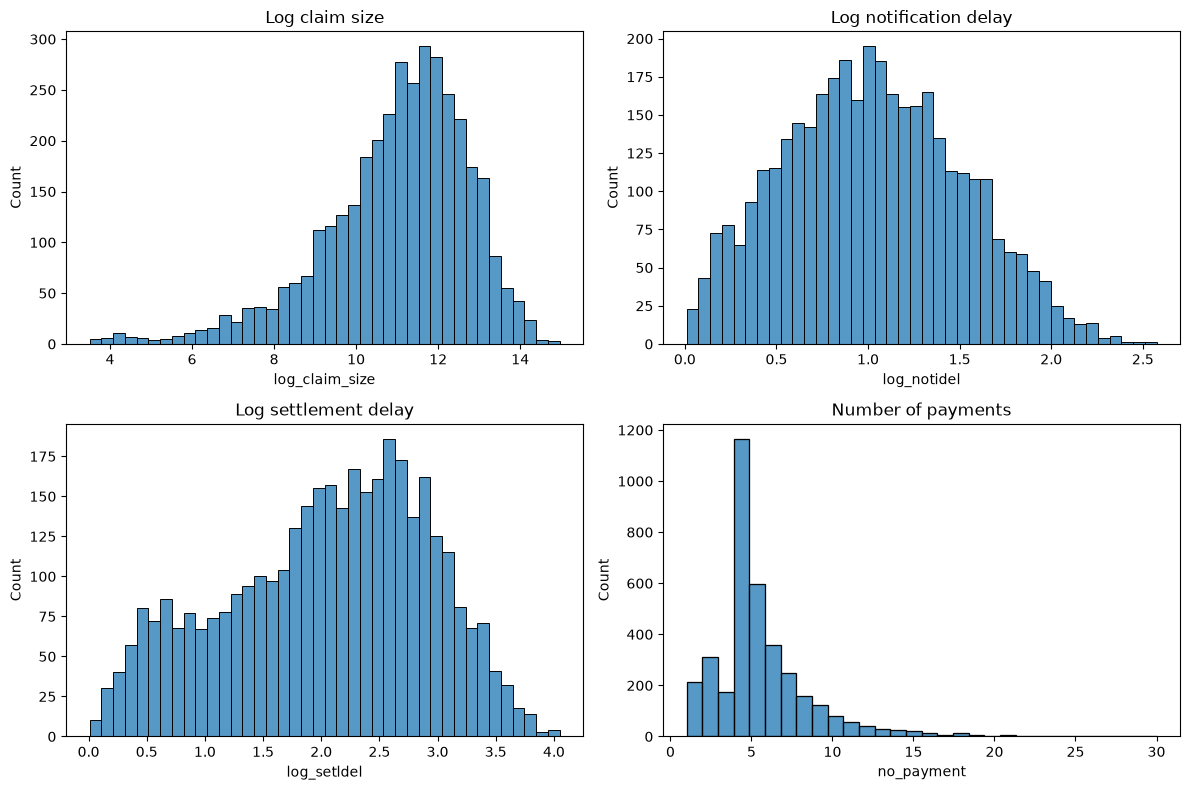

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = claims.assign(
    log_claim_size=np.log1p(claims["claim_size"]),
    log_notidel=np.log1p(claims["notidel"]),
    log_setldel=np.log1p(claims["setldel"]),
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(plot_data["log_claim_size"], bins=40, ax=axes[0, 0])
axes[0, 0].set_title("Log claim size")

sns.histplot(plot_data["log_notidel"], bins=40, ax=axes[0, 1])
axes[0, 1].set_title("Log notification delay")

sns.histplot(plot_data["log_setldel"], bins=40, ax=axes[1, 0])
axes[1, 0].set_title("Log settlement delay")

sns.histplot(plot_data["no_payment"], bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Number of payments")

plt.tight_layout()
plt.show()

### Distribution findings

- Log transformation substantially improves the claim-size and delay distributions.
- `no_payment` remains strongly right-skewed, so `log1p(no_payment)` should also be tested.
- Settlement delay shows possible subgroup structure that may help clustering.
- Extreme claims are retained because they may represent meaningful clusters.

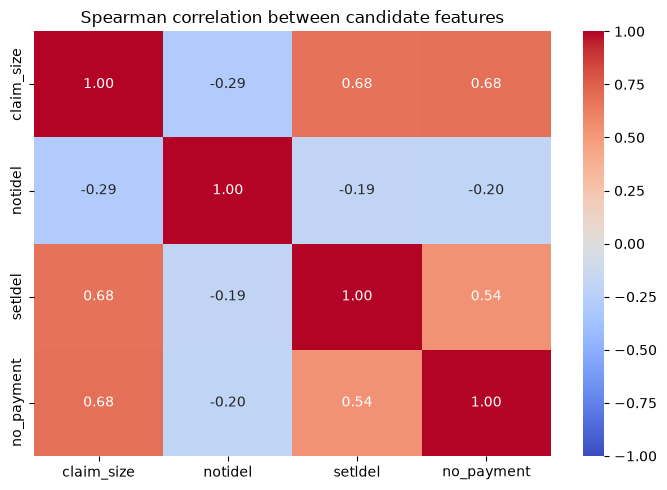

In [15]:
correlation = claims[
    ["claim_size", "notidel", "setldel", "no_payment"] # Spearman correlation, appropriate for skewed and discrete variables
].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)
plt.title("Spearman correlation between candidate features")
plt.tight_layout()
plt.show()

### Correlation findings

Claim size has a strong positive association with both settlement delay
(`0.68`) and the number of payments (`0.68`). Larger claims therefore tend to
remain open longer and involve more payment transactions.

Settlement delay and payment count are also moderately correlated (`0.54`).
Notification delay has weaker negative relationships with the other features.

These correlations are actuarially plausible, but they mean that claim size,
settlement delay and payment count partly represent the same underlying claim
complexity. Including all three may give this dimension additional weight in
distance-based clustering. The initial model will retain them, followed by a
sensitivity analysis with alternative feature combinations.

## Candidate unit of analysis: occurrence period

Individual-claim clustering provides many observations but uses final claim
outcomes such as ultimate size and settlement delay.

An actuarial alternative is to aggregate claims by occurrence period. Each row
then represents a portfolio cohort characterised by frequency, severity and
development behaviour.

The following table creates candidate period-level features.

In [16]:
period_summary = (
    claims.groupby("occurrence_period")
    .agg(
        claim_frequency=("claim_no", "size"),
        median_claim_size=("claim_size", "median"),
        mean_claim_size=("claim_size", "mean"),
        median_notification_delay=("notidel", "median"),
        median_settlement_delay=("setldel", "median"),
        mean_payment_count=("no_payment", "mean"),
    )
    .reset_index()
)

print("Period-level table:", period_summary.shape)
display(period_summary.head())

Period-level table: (40, 7)


,occurrence_period,claim_frequency,median_claim_size,mean_claim_size,median_notification_delay,median_settlement_delay,mean_payment_count
0,1,103,71820.750283,136663.920213,1.862734,8.411517,5.194175
1,2,84,84107.864482,150685.202360,1.372495,10.071930,4.928571
2,3,90,64695.073997,146067.211217,1.744627,7.836139,4.888889
3,4,79,78898.329828,196326.404408,1.828820,6.554844,5.113924
4,5,88,91859.228598,183742.267475,1.954023,7.257505,5.511364


### Portfolio development across occurrence periods

The following plots examine whether frequency, severity and claim-development
behaviour change systematically over time. Such changes may create meaningful
portfolio segments for reserving.

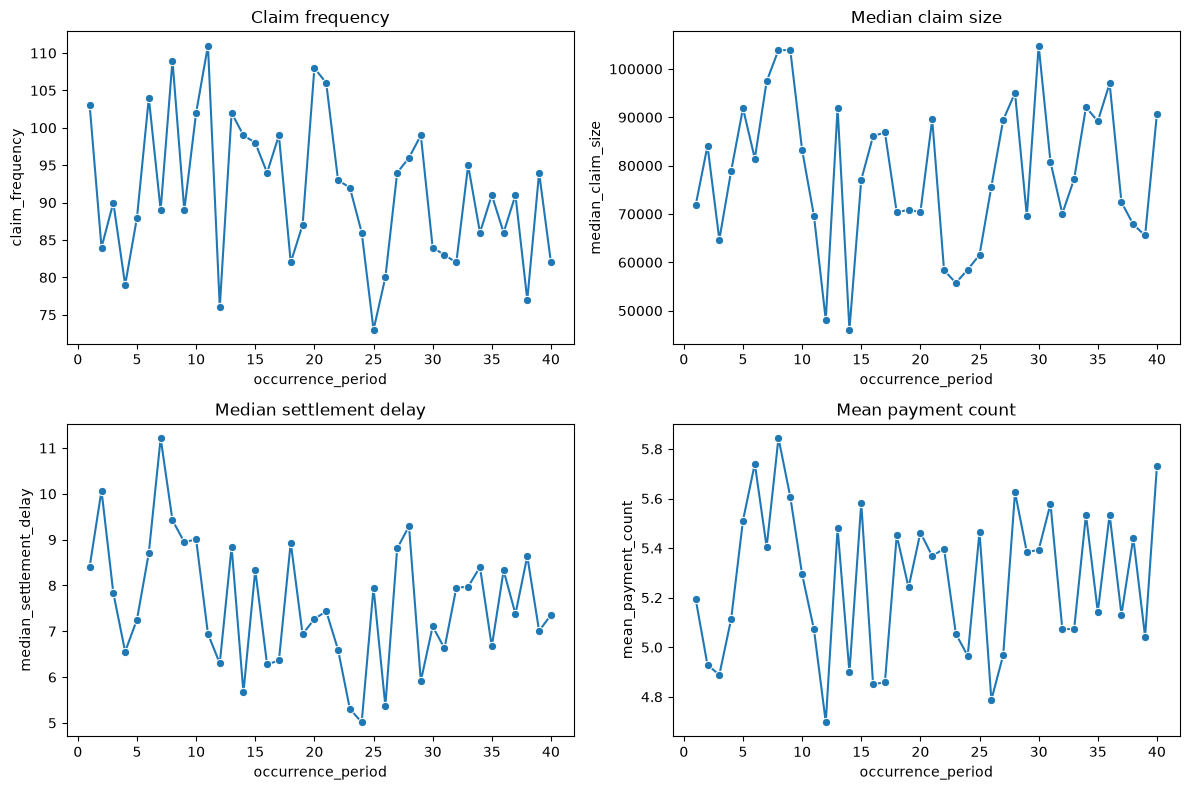

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.lineplot(
    data=period_summary,
    x="occurrence_period",
    y="claim_frequency",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Claim frequency")

sns.lineplot(
    data=period_summary,
    x="occurrence_period",
    y="median_claim_size",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Median claim size")

sns.lineplot(
    data=period_summary,
    x="occurrence_period",
    y="median_settlement_delay",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Median settlement delay")

sns.lineplot(
    data=period_summary,
    x="occurrence_period",
    y="mean_payment_count",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Mean payment count")

plt.tight_layout()
plt.show()

### Decision on the clustering unit

Occurrence-period characteristics fluctuate over time, but the plots do not
show clear and persistent portfolio regimes. Aggregation would also reduce the
dataset from 3,663 claims to only 40 observations and conceal substantial
claim-level heterogeneity.

The primary clustering unit will therefore be the **individual claim**.

The initial features are:

- claim severity;
- notification delay;
- settlement delay;
- number of payments.

Occurrence-period summaries will remain a secondary diagnostic for evaluating
the temporal distribution of the resulting clusters.

Because claim size, settlement delay and payment count are final outcomes, this
initial analysis represents **ex-post claim segmentation**. It should not yet
be interpreted as a model that assigns clusters at claim notification.